# Weather Underground PWS Data Pipeline

Fetch historical weather data from Weather Underground Personal Weather Stations (PWS) via API.

**Source:** https://api.weather.com/v2/pws

## Key Features
- Historical hourly data (aggregated from minute-level observations)
- Clean column names with precipitation data prioritized
- Automatic chunking for date ranges > 31 days
- Quality checks and validation
- Multi-station support

## Pipeline Steps
1. Configure API key and stations
2. Fetch historical data (auto-chunked if needed)
3. Convert to clean DataFrames with standardized column names
4. Quality checks and data validation
5. Analyze precipitation patterns
6. Plot and save results

## 1. Configuration

Configure API key, stations, date range, and output directory.

**Stations:**
- **Specific:** `STATION_IDS = ['KNYNEWYO1805', 'KNYNEWYO1850']` (list of PWS IDs).
- **All:** `STATION_IDS = 'all'` or `STATION_IDS = None` → load all from `dataset/meta/pws_metadata.csv`.

**Date Range:** Start and end dates (datetime objects).

**Output Directory:** `dataset/raw/fetched/wu/` (main dataset folder).

**API Key:** Set via environment variable `WU_API_KEY` or in config.py.

In [1]:
# Setup: Import libraries and configure pipeline
from datetime import datetime
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Add parent (fetch_data) to path for shared config
sys.path.insert(0, str(Path.cwd().parent))

# Shared config and WU functions (same pattern as asos_pipeline)
from config import OUTPUT_DIRS
from wu_fetch import *
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# CONFIGURATION - EDIT THESE VALUES
# ============================================================
# Stations: list of IDs, or 'all' / None to load ALL from dataset/meta/pws_metadata.csv
#STATION_IDS = ['KNYNEWYO1805', 'KNYNEWYO1850']  # specific stations
STATION_IDS = 'all'   # or None — fetch ALL stations from pws_metadata.csv

START_DATE  = datetime(2024, 1, 1)
END_DATE    = datetime(2024, 1, 30)

# Output directory: main dataset folder (same as CLI/main.py)
OUTPUT_DIR = OUTPUT_DIRS['wu']
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# ============================================================

# Resolve stations: specific list vs all from metadata
use_all = STATION_IDS is None or STATION_IDS == [] or STATION_IDS == 'all'
if use_all:
    pws_meta = read_pws_metadata()
    STATION_IDS = get_station_list(pws_meta)
    _station_source = "all (pws_metadata.csv)"
else:
    _station_source = "specific"


In [2]:

# Check API key status
api_status = check_api_key_status()
print(api_status['message'])

if api_status['available']:
    API_KEY = get_api_key()
else:
    API_KEY = None
    print("\nOptions to set API key:")
    print("  1. Environment variable: export WU_API_KEY='your_key'")
    print("  2. Add to config.py: WU_API_KEY = 'your_key'")
    print("See API_KEY_SETUP.md for detailed instructions.")

print(f'\nStations: {len(STATION_IDS)} ({_station_source})')
if _station_source == "specific":
    print(f'  {STATION_IDS}')
else:
    print(f'  First 5: {STATION_IDS[:5]}...')
print(f'Period: {START_DATE.date()} to {END_DATE.date()}')
print(f'Output directory: {OUTPUT_DIR.resolve()}')
print('\n✓ Setup complete')

✓ API key found (environment_variable)

Stations: 37 (all (pws_metadata.csv))
  First 5: ['KNYNEWYO1805', 'KNYNEWYO1288', 'KNYNEWYO1238', 'KNYNEWYO1622', 'KNYNEWYO1796']...
Period: 2024-01-01 to 2024-01-30
Output directory: /Users/drorjac/PycharmProjects/OpenMesh-clean/dataset/raw/fetched/wu

✓ Setup complete


## 2. Fetch Raw Data

Fetch historical weather data from Weather Underground API.

**Note:** Data is fetched in chunks if the date range exceeds 31 days (API limit). The pipeline automatically handles chunking and merging.

**Data Resolution:** Hourly (aggregated from minute-level PWS observations)

**API Key Required:** Weather Underground requires an API key for authentication.

### 2.0 API Test (Optional - Can Skip)

This cell tests the WU API to verify it's working correctly. You can skip this cell if you trust the API is functioning.

In [3]:
# Optional: Test API connection with a single station, single day
if API_KEY:
    print("Testing API connection...")
    test_result = get_historical_data_chunk(
        api_key=API_KEY,
        station_id=STATION_IDS[0],
        start_date=START_DATE,
        end_date=START_DATE + timedelta(days=1),
        units='m',
        data_type='hourly'
    )
    
    if test_result and 'observations' in test_result:
        print(f"✓ API test successful! Got {len(test_result['observations'])} observations")
        print(f"  Sample observation keys: {list(test_result['observations'][0].keys())[:5]}...")
    else:
        print("✗ API test failed or no data returned")
else:
    print("✗ API key not set - cannot test")

Testing API connection...
✓ API test successful! Got 48 observations
  Sample observation keys: ['stationID', 'tz', 'obsTimeUtc', 'obsTimeLocal', 'epoch']...


### 2.1 Fetch Data

Fetch historical data for all configured stations.

In [4]:
# Fetch data using the pipeline
if not API_KEY:
    print("❌ API key not found. Cannot fetch data.")
    results = None
else:
    results = run_wu_pipeline(
        api_key=API_KEY,
        station_ids=STATION_IDS,
        start_date=START_DATE,
        end_date=END_DATE,
        units='m',  # 'm' for metric, 'e' for imperial
        fetch_options={'historical': True},
        output_dir=None,  # We'll save manually later
        save_data=False
    )

WEATHER UNDERGROUND DATA
Period: 2024-01-01 to 2024-01-30 (29 days)
Stations: 37
  [████████████████████] 37/37 Done! ✓ 24,717 obs     687
Fetched 24,717 obs in 17.4s (37/37 stations)
Processed 37 stations


### 2.2 Quick Look at Raw Data

Inspect the raw data structure: columns, shape, and date ranges.

In [5]:
# Quick look at fetched data
if results and 'dataframes' in results:
    all_dfs = results['dataframes']
    
    for station_id, dfs in all_dfs.items():
        if 'clean' in dfs:
            df = dfs['clean']
            print(f"\n{station_id}:")
            print(f"  Shape: {df.shape}")
            print(f"  Columns: {list(df.columns)[:10]}...")
            
            # Find datetime column
            dt_col = None
            for col in ['datetime', 'time_local', 'obsTimeLocal']:
                if col in df.columns:
                    dt_col = col
                    break
            
            if dt_col:
                print(f"  Date range: {df[dt_col].min()} to {df[dt_col].max()}")
else:
    print("⚠ No data fetched")


KNYNEWYO1805:
  Shape: (720, 37)
  Columns: ['precip_rate', 'precip_amount', 'time_local', 'datetime', 'timestamp_unix', 'station_id', 'latitude', 'longitude', 'timezone', 'temperature']...
  Date range: 2024-01-01 05:58:23+00:00 to 2024-01-31 04:59:00+00:00

KNYNEWYO1288:
  Shape: (720, 37)
  Columns: ['precip_rate', 'precip_amount', 'time_local', 'datetime', 'timestamp_unix', 'station_id', 'latitude', 'longitude', 'timezone', 'temperature']...
  Date range: 2024-01-01 05:59:00+00:00 to 2024-01-31 04:59:00+00:00

KNYNEWYO1238:
  Shape: (716, 37)
  Columns: ['precip_rate', 'precip_amount', 'time_local', 'datetime', 'timestamp_unix', 'station_id', 'latitude', 'longitude', 'timezone', 'temperature']...
  Date range: 2024-01-01 05:59:35+00:00 to 2024-01-31 04:59:55+00:00

KNYNEWYO1622:
  Shape: (720, 37)
  Columns: ['precip_rate', 'precip_amount', 'time_local', 'datetime', 'timestamp_unix', 'station_id', 'latitude', 'longitude', 'timezone', 'temperature']...
  Date range: 2024-01-01 05:5

## 3. Process and Validate Data

Extract processed (clean) DataFrames and perform quality checks.

**Clean Data:** Standardized column names with precipitation data prioritized

**Quality Checks:** Validate date ranges, check for missing data, verify precipitation values

In [6]:
# Extract processed data (clean DataFrames)
processed_data = {}

if results and 'dataframes' in results:
    processed_data = {
        sid: dfs['clean'] 
        for sid, dfs in results['dataframes'].items() 
        if 'clean' in dfs
    }
    
    print("\n" + "=" * 60)
    print("PROCESSING RESULTS")
    print("=" * 60)
    print(f"\n✓ Processed {len(processed_data)} station(s)")
    
    # Summary for each station
    for station_id, df in processed_data.items():
        print(f"\n  {station_id}:")
        print(f"    Rows: {len(df):,}")
        
        # Precipitation
        precip_col = next((c for c in ['precip_rate', 'precip_amount', 'precipitation'] if c in df.columns), None)
        if precip_col:
            total_precip = df[precip_col].sum()
            rainy_hours = (df[precip_col] > 0).sum()
            print(f"    Total precip: {total_precip:.1f} mm ({rainy_hours} rainy hours)")
        
        # Temperature
        if 'temperature' in df.columns:
            print(f"    Temp range: {df['temperature'].min():.1f}°C to {df['temperature'].max():.1f}°C")
else:
    print("⚠ No processed data available")


PROCESSING RESULTS

✓ Processed 37 station(s)

  KNYNEWYO1805:
    Rows: 720
    Total precip: 165.2 mm (99 rainy hours)
    Temp range: -8.0°C to 14.0°C

  KNYNEWYO1288:
    Rows: 720
    Total precip: 498.7 mm (98 rainy hours)
    Temp range: -8.0°C to 15.0°C

  KNYNEWYO1238:
    Rows: 716
    Total precip: 929.9 mm (56 rainy hours)
    Temp range: 2.0°C to 5.0°C

  KNYNEWYO1622:
    Rows: 720
    Total precip: 2.8 mm (8 rainy hours)
    Temp range: -6.0°C to 15.0°C

  KNYNEWYO1796:
    Rows: 720
    Total precip: 412.8 mm (112 rainy hours)
    Temp range: -7.0°C to 16.0°C

  KNYNEWYO1747:
    Rows: 720
    Total precip: 181.4 mm (103 rainy hours)
    Temp range: -8.0°C to 15.0°C

  KNYNEWYO1626:
    Rows: 720
    Total precip: 165.7 mm (276 rainy hours)
    Temp range: -8.0°C to 14.0°C

  KNYNEWYO1533:
    Rows: 720
    Total precip: 219.1 mm (124 rainy hours)
    Temp range: -7.0°C to 16.0°C

  KNYNEWYO1867:
    Rows: 720
    Total precip: 253.0 mm (63 rainy hours)
    Temp range:

## 4. Save Data

Save processed data to CSV files.

**Filename Format:** `WU_YYYY-MM-DD_YYYY-MM-DD.csv`

In [7]:
# Save processed data
if processed_data:
    save_wu(
        processed_data=processed_data,
        output_dir=OUTPUT_DIR,
        overwrite=True
    )
else:
    print("⚠ No data to save")


Saving PROCESSED data to: /Users/drorjac/PycharmProjects/OpenMesh-clean/dataset/raw/fetched/wu
----------------------------------------
  ✓ WU_2024-01-01_2024-01-30.csv (24,717 rows)
----------------------------------------
✓ Save complete: /Users/drorjac/PycharmProjects/OpenMesh-clean/dataset/raw/fetched/wu



## 5. Visualization

Plot precipitation and weather data to visualize patterns and compare stations.

**Available plots:**
- Precipitation analysis (rate and cumulative)
- Multi-station comparison
- Weather dashboard (temperature, humidity, wind, pressure)

### 5.1 Precipitation Analysis

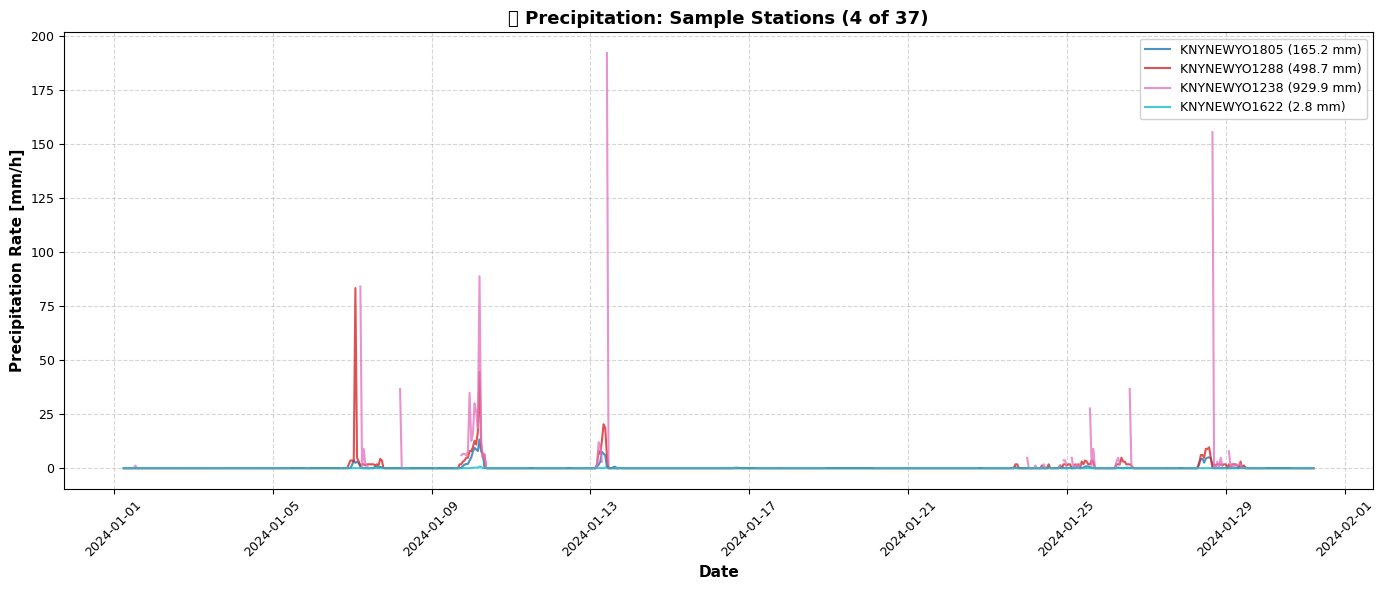

💧 KNYNEWYO1805: 148.4 mm total, 96 events
💧 KNYNEWYO1288: 196.6 mm total, 96 events
💧 KNYNEWYO1238: 84.7 mm total, 42 events
💧 KNYNEWYO1622: 1.5 mm total, 5 events


In [8]:
# Plot precipitation analysis for all stations
if processed_data:
    # Wrap DataFrames in expected format: {station_id: {'clean': df}}
    station_data_for_plot = {sid: {'clean': df} for sid, df in processed_data.items()}
    
    plot_precipitation_analysis_multi(
        station_data=station_data_for_plot,
        units='m',
        show=True
    )
else:
    print("⚠ No data to plot")

### 5.2 Cumulative Precipitation

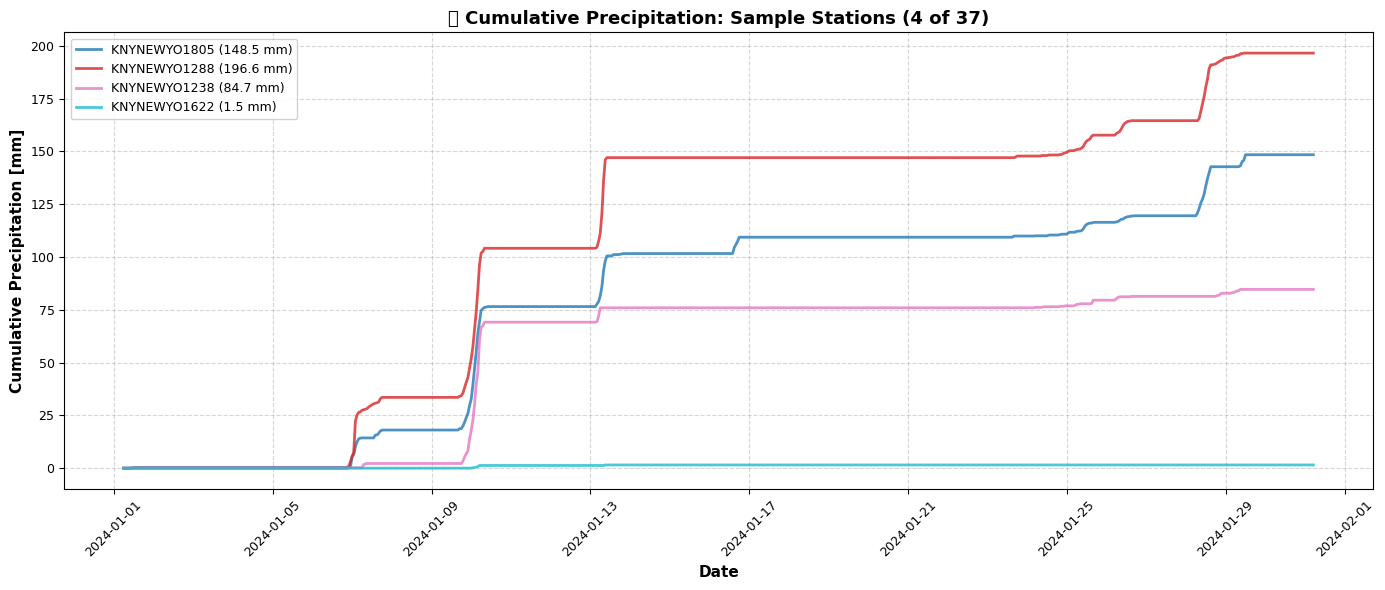

📈 KNYNEWYO1805: 148.4 mm total, 96 events
📈 KNYNEWYO1288: 196.6 mm total, 96 events
📈 KNYNEWYO1238: 84.7 mm total, 42 events
📈 KNYNEWYO1622: 1.5 mm total, 5 events


In [9]:
# Plot cumulative precipitation
if processed_data:
    station_data_for_plot = {sid: {'clean': df} for sid, df in processed_data.items()}
    
    plot_cumulative_precipitation_multi(
        station_data=station_data_for_plot,
        units='m',
        show=True
    )
else:
    print("⚠ No data to plot")

### 5.3 Weather Dashboard (Single Station)

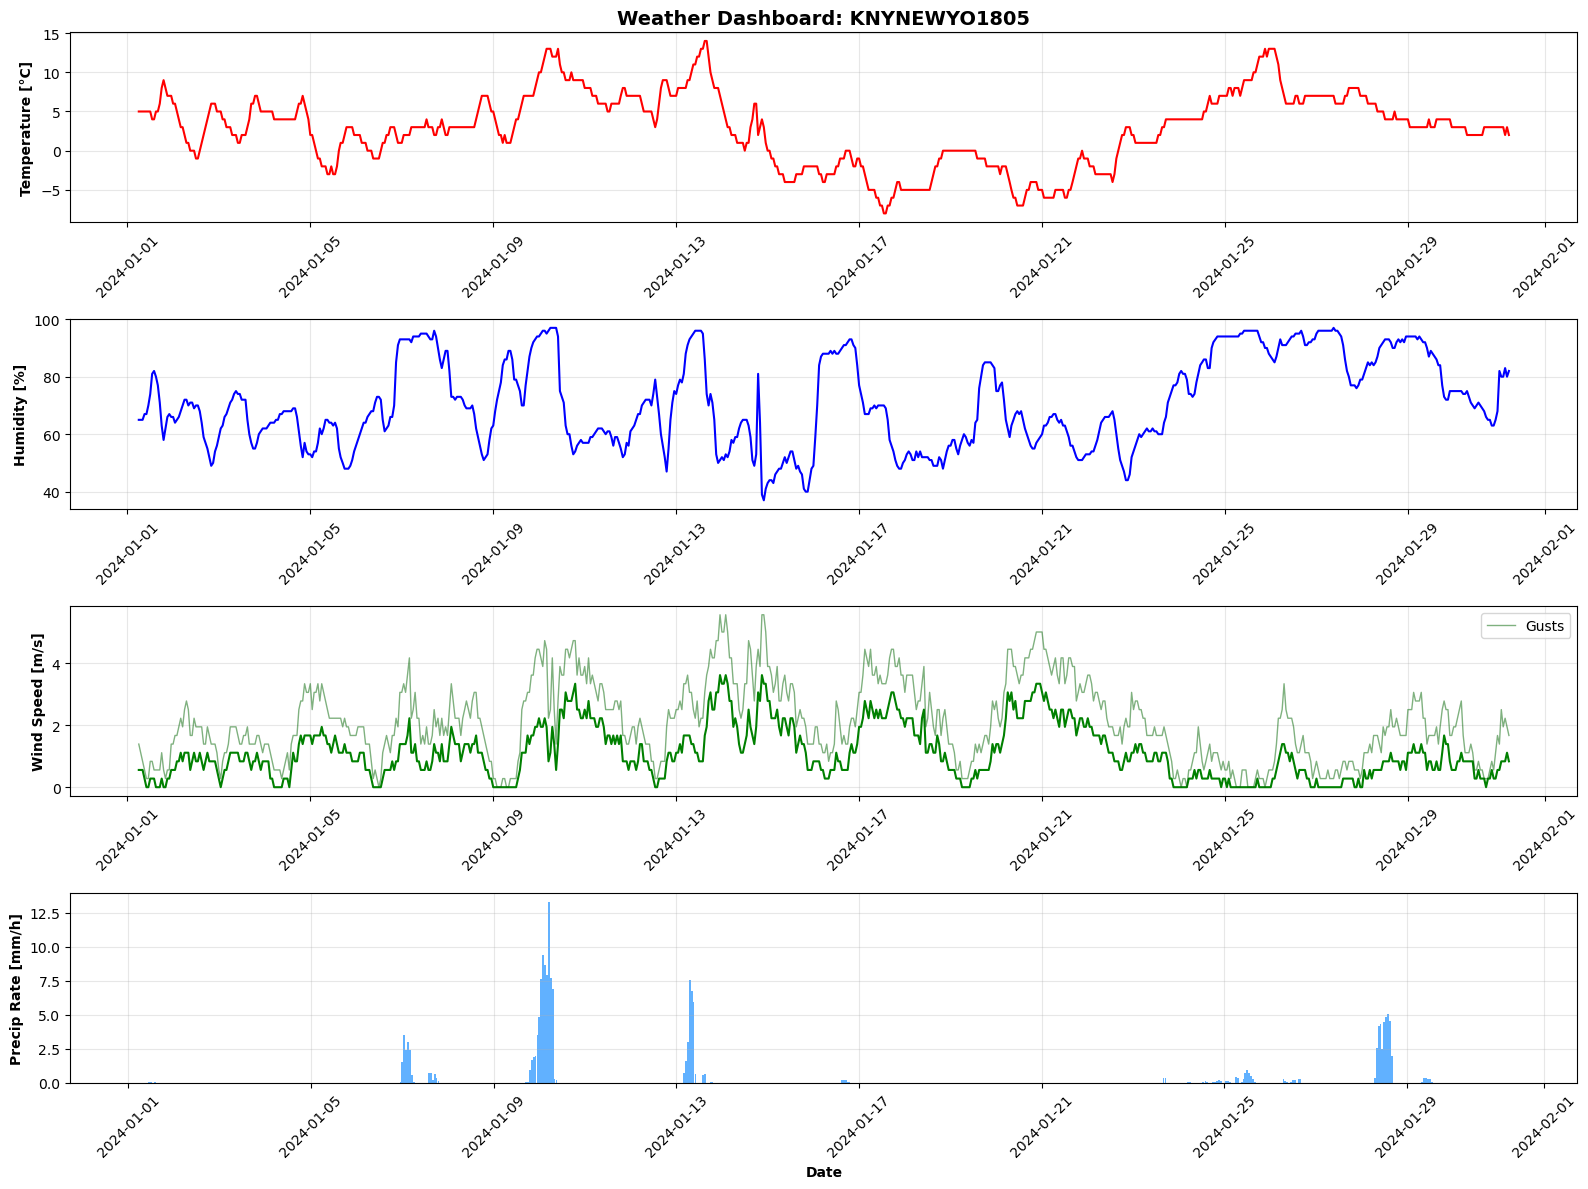

In [10]:
# Plot weather dashboard for first station
if processed_data:
    first_station = list(processed_data.keys())[0]
    df_first = processed_data[first_station]
    
    plot_weather_dashboard(
        df=df_first,
        station_id=first_station,
        units='m',
        show=True
    )
else:
    print("⚠ No data to plot")

## 6. Summary

Final summary of the pipeline execution.

In [11]:
# Summary
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nPeriod: {START_DATE.date()} to {END_DATE.date()}")
print(f"Stations: {len(processed_data)}")

if processed_data:
    # Show first few columns
    sample_cols = list(list(processed_data.values())[0].columns)[:8]
    print(f"\nVariables: {', '.join(sample_cols)}...")
    
    print(f"\nPrecipitation totals:")
    for station_id, df in processed_data.items():
        precip_col = next((c for c in ['precip_rate', 'precip_amount', 'precipitation'] if c in df.columns), None)
        if precip_col:
            total = df[precip_col].sum()
            print(f"  {station_id}: {total:.1f} mm")
        else:
            print(f"  {station_id}: No precipitation data")

print(f"\nOutput directory: {OUTPUT_DIR.resolve()}")
print("\n" + "=" * 60)
print("✓ COMPLETE")

SUMMARY

Period: 2024-01-01 to 2024-01-30
Stations: 37

Variables: precip_rate, precip_amount, time_local, datetime, timestamp_unix, station_id, latitude, longitude...

Precipitation totals:
  KNYNEWYO1805: 165.2 mm
  KNYNEWYO1288: 498.7 mm
  KNYNEWYO1238: 929.9 mm
  KNYNEWYO1622: 2.8 mm
  KNYNEWYO1796: 412.8 mm
  KNYNEWYO1747: 181.4 mm
  KNYNEWYO1626: 165.7 mm
  KNYNEWYO1533: 219.1 mm
  KNYNEWYO1867: 253.0 mm
  KNYNEWYO1896: 265.8 mm
  KNYNEWYO1401: 382.0 mm
  KNYNEWYO1606: 335.2 mm
  KNYNEWYO1127: 208.0 mm
  KNYNEWYO343: 43.9 mm
  KNYNEWYO1591: 388.6 mm
  KNYNEWYO589: 376.1 mm
  KNYNEWYO638: 519.9 mm
  KNYNEWYO1120: 311.5 mm
  KNYNEWYO1298: 372.4 mm
  KNYNEWYO1313: 414.4 mm
  KNYNEWYO1326: 139.8 mm
  KNYNEWYO1348: 185.3 mm
  KNYNEWYO1388: 301.6 mm
  KNYNEWYO1472: 194.0 mm
  KNYNEWYO1659: 343.4 mm
  KNYNEWYO1681: 207.4 mm
  KNYNEWYO505: 173.4 mm
  KNYNEWYO1024: 101.5 mm
  KNYNEWYO1053: 413.9 mm
  KNYNEWYO1651: 177.4 mm
  KNYNEWYO1824: 441.4 mm
  KNYNEWYO1900: 261.8 mm
  KNYNEWYO1918: 

## 7. Load Data (Optional)

Load previously saved data instead of fetching/processing again.

**Use this section if:**
- You've already run the fetch/preprocess steps
- You want to skip to visualization
- You're working with saved data from a previous run